# Base CNN Training for Posture Classification (FP32)

**Architecture**
- 3 Conv2D layers with BatchNormalization
- Filter progression: [16, 16, 24]
- GlobalAveragePooling2D for efficiency
- Output: Dense(NUM_CLASSES, softmax)

**Hyperparameters**
- Learning rate: 0.001
- Batch size: 32
- Kernel size: (3, 3)
- L1 regularization: 1e-4
- Early stopping patience: 10

## Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Keras 3
import keras
import keras_tuner

# TensorFlow
import tensorflow as tf

# Package imports
from neuroposasic import (
    load_dataset,
    preprocess_data,
    create_model,
    get_callbacks,
    train_model,
    check_layer_trainable_params,
    plot_training_history,
    class_report_metric,
    save_model,
)

# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)


I0000 00:00:1777056946.737135  155936 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Set random seed for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

# Constant number of postures
NUM_CLASSES = 3

# Check GPU
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data

### Loading

In [3]:
# Load datasets using package function
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset(type="raw")


Dataset shapes:
  Train: (40325, 64), labels: (40325,)
  Val:   (20162, 64), labels: (20162,)
  Test:  (40326, 64), labels: (40326,)


### Preprocessing

In [4]:
# Preprocess data using package function
(X_train, y_train, X_val, y_val, X_test, y_test, class_names) = preprocess_data(
    X_train, y_train, X_val, y_val, X_test, y_test,
    num_classes=NUM_CLASSES,
)


Label encoding:
  lateral_L -> 0
  lateral_R -> 1
  supine -> 2

One-hot encoded shape: 3

Reshaped data:
  Train: (40325, 8, 8, 1)
  Val:   (20162, 8, 8, 1)
  Test:  (40326, 8, 8, 1)

Data range: [0.0000, 235.8969]
Data dtype: float32


## Configuration

In [5]:
# Define callbacks using package function
callbacks = get_callbacks(model_name='base', patience=10)

Callbacks configured:
  - EarlyStopping
  - ReduceLROnPlateau
  - ModelCheckpoint


## Base Model

In [6]:
# Create and inspect model
base_model = create_model(num_classes=NUM_CLASSES)
base_model.summary()

check_layer_trainable_params(base_model)

I0000 00:00:1777056948.635813  155936 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5508 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:10:00.0, compute capability: 8.6


Model: "posture_classifier_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 6, 6, 16)       │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (BatchNormalization)  │ (None, 6, 6, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (Activation)         │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 4, 4, 16)       │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (BatchNormalization)  │ (None, 4, 4, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_2 (Activation)         │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 2, 2, 24)       │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_3 (BatchNormalization)  │ (None, 2, 2, 24)       │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_3 (Activation)         │ (None, 2, 2, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 1, 1, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 24)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            75 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,203 (24.23 KB)

 Trainable params: 6,091 (23.79 KB)

 Non-trainable params: 112 (448.00 B)

conv_1: 144
conv_2: 2304
conv_3: 3456
output: 72


### Training

Epoch 1/50


I0000 00:00:1777056950.172685  156008 service.cc:153] XLA service 0x7ff7e40377d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777056950.172697  156008 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777056950.201035  156008 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777056950.399250  156008 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1777056950.412312  156008 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2780__.47


  77/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4298 - loss: 1.2620

I0000 00:00:1777056954.041852  156008 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1257/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6411 - loss: 0.8480

I0000 00:00:1777056956.190158  156007 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2780__.47


1261/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6414 - loss: 0.8476
Epoch 1: val_loss improved from None to 0.55472, saving model to best_base_model.keras

Epoch 1: finished saving model to best_base_model.keras
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7174 - loss: 0.7023 - val_accuracy: 0.7856 - val_loss: 0.5547 - learning_rate: 0.0010
Epoch 2/50
1243/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7918 - loss: 0.5468
Epoch 2: val_loss improved from 0.55472 to 0.49038, saving model to best_base_model.keras

Epoch 2: finished saving model to best_base_model.keras
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8015 - loss: 0.5284 - val_accuracy: 0.8186 - val_loss: 0.4904 - learning_rate: 0.0010
Epoch 3/50
1245/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8186 - loss: 0.4849
Epoch 3: val_loss improved from 0.49038 to 0.45854, saving model to best_base_model.keras

Epoch 3: finished saving model to best_base_model.keras
1261/1261 ━━━━━━━━━━━━

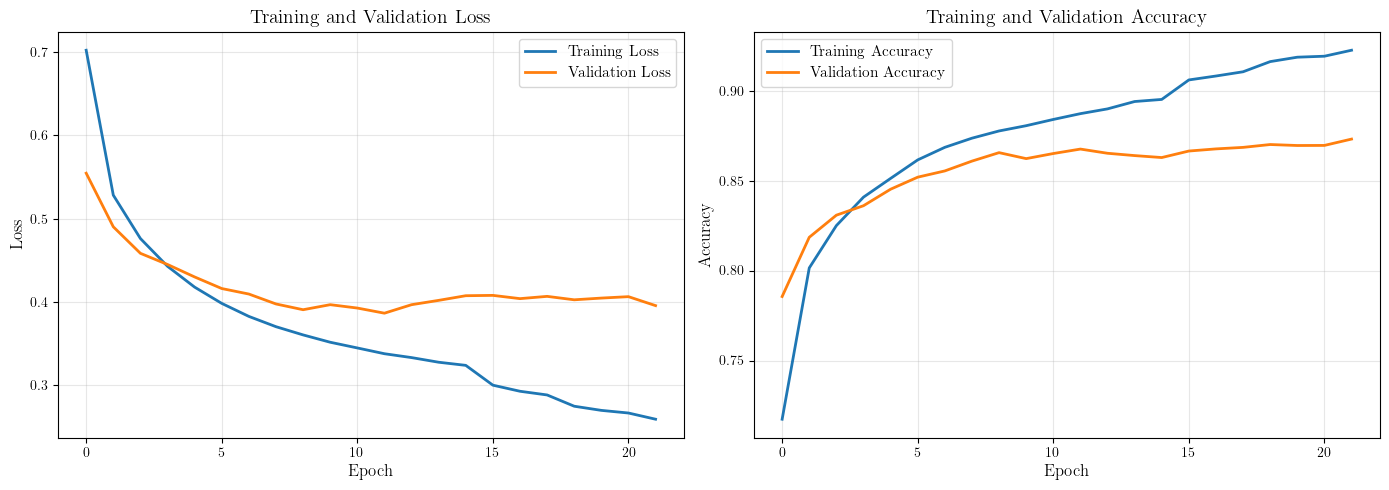

In [7]:
# Train the model
base_history = train_model(
    base_model, X_train, y_train, X_val, y_val, callbacks,
    batch_size=32, max_epochs=50,
)
plot_training_history(base_history, model_name='posture_classifier_base', save=True)

## Tuned Model

Hyperparameter optimization (KerasTuner)

In [8]:
tuner = keras_tuner.Hyperband(
    hypermodel=create_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    hyperband_iterations=2,
    overwrite=False,
    directory='tuning',
    project_name='posture_cnn',
    )

tuner.search_space_summary()

Reloading Tuner from tuning/posture_cnn/tuner0.json
Search space summary
Default search space size: 4
filters_1 (Int)
{'default': None, 'conditions': [], 'min_value': 4, 'max_value': 64, 'step': 8, 'sampling': 'linear'}
filters_2 (Int)
{'default': None, 'conditions': [], 'min_value': 4, 'max_value': 64, 'step': 8, 'sampling': 'linear'}
filters_3 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 128, 'step': 8, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001], 'ordered': True}


In [9]:
tuner.search(X_train, y_train, epochs=10, validation_data=(X_val, y_val))
tuned_model = tuner.get_best_models()[0]

tuned_model.summary()

check_layer_trainable_params(tuned_model)

/home/jeison/Nextcloud/PUCMM/ProyectoGrado/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "posture_classifier_tuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 6, 6, 60)       │           540 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (BatchNormalization)  │ (None, 6, 6, 60)       │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (Activation)         │ (None, 6, 6, 60)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 4, 4, 28)       │        15,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (BatchNormalization)  │ (None, 4, 4, 28)       │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_2 (Activation)         │ (None, 4, 4, 28)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 2, 2, 96)       │        24,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_3 (BatchNormalization)  │ (None, 2, 2, 96)       │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_3 (Activation)         │ (None, 2, 2, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 1, 1, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 96)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,879 (159.68 KB)

 Trainable params: 40,511 (158.25 KB)

 Non-trainable params: 368 (1.44 KB)

conv_1: 540
conv_2: 15120
Layer conv_2 is too large (15120), are you sure you want to train?
conv_3: 24192
Layer conv_3 is too large (24192), are you sure you want to train?
output: 288


### Training

Epoch 1/50


I0000 00:00:1777057014.600683  156008 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_174605__.47


1238/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9346 - loss: 0.3532

I0000 00:00:1777057019.841307  156006 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_174605__.47


1261/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9346 - loss: 0.3531
Epoch 1: val_loss did not improve from 0.38669
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9365 - loss: 0.3488 - val_accuracy: 0.8810 - val_loss: 0.5092 - learning_rate: 0.0010
Epoch 2/50
1242/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9419 - loss: 0.3417
Epoch 2: val_loss did not improve from 0.38669
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9416 - loss: 0.3419 - val_accuracy: 0.8785 - val_loss: 0.5276 - learning_rate: 0.0010
Epoch 3/50
1239/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9434 - loss: 0.3355
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_loss did not improve from 0.38669
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9431 - loss: 0.3353 - val_accuracy: 0.8777 - val_loss: 0.5366 - learning_rate: 0.0010
Epoch 4/50
1255/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9577 - loss: 0.3057
Epoch 4: va

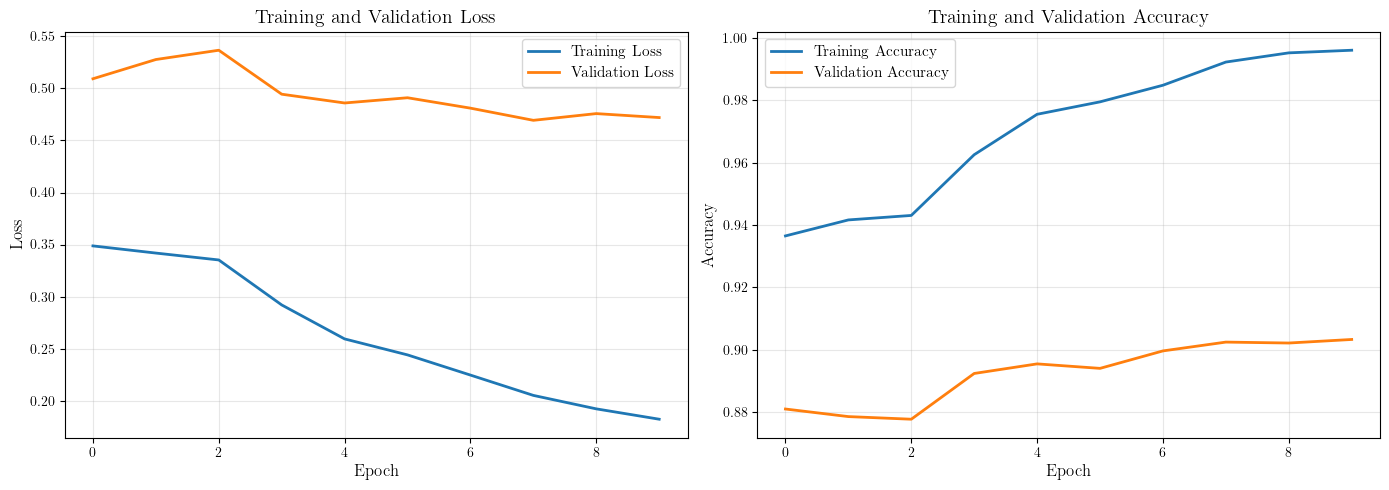

In [10]:
tuned_history = train_model(tuned_model, X_train, y_train, X_val, y_val, callbacks)
plot_training_history(tuned_history, model_name='posture_classifier_tuned', save=True)

## Model Evaluation

### Base Model

In [11]:
# Classification report for base model
class_report_metric(base_model, X_test, y_test, class_names)


Accuracy Report for `posture_classifier_base`:
  Loss: 0.3802
  Accuracy: 87.09%

Classification Report for `posture_classifier_base`:
              precision    recall  f1-score   support

   lateral_L     0.8853    0.8854    0.8854     17406
   lateral_R     0.8664    0.8613    0.8638     12678
      supine     0.8520    0.8581    0.8550     10242

    accuracy                         0.8709     40326
   macro avg     0.8679    0.8683    0.8681     40326
weighted avg     0.8709    0.8709    0.8709     40326



### Tuned Model

In [12]:
# Classification report for tuned model
class_report_metric(tuned_model, X_test, y_test, class_names)


Accuracy Report for `posture_classifier_tuned`:
  Loss: 0.5080
  Accuracy: 88.32%

Classification Report for `posture_classifier_tuned`:
              precision    recall  f1-score   support

   lateral_L     0.8613    0.9357    0.8970     17406
   lateral_R     0.8866    0.8792    0.8829     12678
      supine     0.9249    0.7990    0.8574     10242

    accuracy                         0.8832     40326
   macro avg     0.8910    0.8713    0.8791     40326
weighted avg     0.8854    0.8832    0.8825     40326



## Model Saving

In [13]:
# Save models
save_model(base_model, output_dir='output')
save_model(tuned_model, output_dir='output')


Model saved to: output/posture_classifier_base.keras

Verification:
  Loaded successfully: True
  Model name: posture_classifier_base
  Total parameters: 6,203

Model saved to: output/posture_classifier_tuned.keras

Verification:
  Loaded successfully: True
  Model name: posture_classifier_tuned
  Total parameters: 40,879
